# Q3: Feature Engineering and Regression

In this task, we build a regression pipeline to predict items sold. We create new date-based features, split the data based on time, preprocess using pipelines, and train regression models.

  transaction_date  store_id store_size location_type  promotion_type  \
0       2022-01-01        28      small    semi-urban       free_gift   
1       2022-01-01         5     medium    semi-urban       free_gift   
2       2022-01-02        13      small    semi-urban  loyalty_points   
3       2022-01-02        17      small         urban       free_gift   
4       2022-01-03        50     medium    semi-urban            bogo   

   is_weekend  is_festival  competition_density  items_sold  year  month  \
0           1            0                    5         224  2022      1   
1           1            1                    1         348  2022      1   
2           1            0                    6         249  2022      1   
3           1            0                    7         259  2022      1   
4           0            0                    3         277  2022      1   

   day_of_week  is_month_end  
0            5         False  
1            5         False  
2          

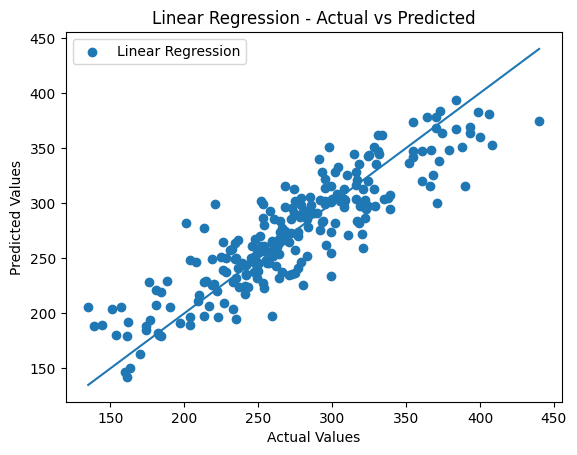


 Random Forest
RMSE: 31.660007317329118
MAE: 24.87391666666667


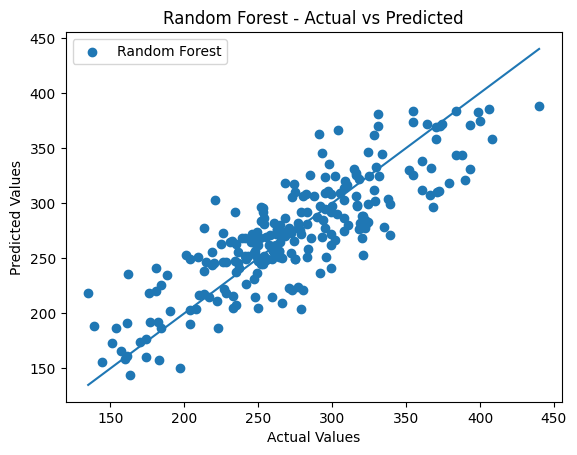


Top 5 Important Features:
                     Feature  Importance
7      cat__store_size_small    0.183954
10          num__is_festival    0.174477
5   cat__location_type_urban    0.140498
14          num__day_of_week    0.090612
9            num__is_weekend    0.063547


In [5]:
# -----------------------
# Import libraries
# -----------------------
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# -----------------------
# Load data
# -----------------------
df = pd.read_csv('../data/q3_retail_promotions.csv')

# -----------------------
# Feature Engineering
# -----------------------
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek
df['is_month_end'] = df['transaction_date'].dt.day >= 25

# Show sample
print(df.head())

# -----------------------
# Sort for time-based split
# -----------------------
df = df.sort_values(by='transaction_date')

# -----------------------
# Train-Test Split (80-20)
# -----------------------
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

X_train = train.drop(['items_sold', 'transaction_date'], axis=1)
y_train = train['items_sold']

X_test = test.drop(['items_sold', 'transaction_date'], axis=1)
y_test = test['items_sold']

# -----------------------
# Preprocessing
# -----------------------
categorical_cols = ['promotion_type', 'location_type', 'store_size']
numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first'), categorical_cols),
    ('num', StandardScaler(), numerical_cols)
])

# -----------------------
# Models
# -----------------------
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42)
}

# -----------------------
# Training & Evaluation
# -----------------------
for name, model in models.items():

    pipe = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    # Metrics (fixed RMSE issue)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    mae = mean_absolute_error(y_test, preds)

    print("\n", name)
    print("RMSE:", rmse)
    print("MAE:", mae)

    # Plot
    plt.figure()
    plt.scatter(y_test, preds, label=name)
    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()])
    
    plt.title(f"{name} - Actual vs Predicted")
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.legend()
    plt.show()

# -----------------------
# Feature Importance (Random Forest)
# -----------------------
rf_model = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

rf_model.fit(X_train, y_train)

# Get feature names
encoded_features = rf_model.named_steps['preprocessing'].get_feature_names_out()

importances = rf_model.named_steps['model'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': encoded_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nTop 5 Important Features:")
print(feature_importance_df.head())

## Conclusion

Random Forest performed better than Linear Regression as it captured non-linear patterns in the data. Feature engineering and proper preprocessing improved the model performance significantly.